In [1]:
import cobra

In [3]:
from cobra.io import load_model
# This is an E.Coli model that comes bundled with cobrapy
model = load_model("iJO1366")

In [4]:
model

Name,iJO1366
Memory address,12be04100
Number of metabolites,1805
Number of reactions,2583
Number of genes,1367
Number of groups,37
Objective expression,1.0*BIOMASS_Ec_iJO1366_core_53p95M - 1.0*BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1
Compartments,"cytosol, extracellular space, periplasm"


In [9]:
model.reactions[1]

Reaction identifier,DM_5drib_c
Name,Sink needed to allow 5'-deoxyribose to leave system
Memory address,0x14f990610
Stoichiometry,5drib_c --> 5'-deoxyribose -->
GPR,
Lower bound,0.0
Upper bound,1000.0


In [11]:
# Change the objective function by assigning model.objective to a reaction object (or name of a reaction)
# or a dict of {reaction: objective_coefficient}

# We get a table with reaction, flux, reduced_cost
# Flux is in mmol/gDW/h or millimoles per gram dry weight per hour. Positive means forward.
# Reduced cost means changing this reaction from zero flux would inc/dec our objective. Zero flux means
# the reaction is inactive. Positive reduced cost means forcing the organism to use this reaction would increase
# the objective. Negative reduced cost means forcing the organism to use this reaction would decrease biomass or growth.

# To get the biomass flux, we look for the reaction called 'BIOMASS_XXX'
fluxes = model.optimize()

In [28]:
fluxes

,fluxes,reduced_costs
DM_4crsol_c,0.000219,0.000000
DM_5drib_c,0.000221,0.000000
DM_aacald_c,0.000000,0.000000
DM_amob_c,0.000002,0.000000
DM_mththf_c,0.000440,0.000000
...,...,...
ZN2abcpp,0.000000,-0.008295
ZN2t3pp,0.000000,-0.002074
ZN2tpp,0.000335,0.000000
ZNabcpp,0.000000,-0.008295


In [24]:
# Experiment 1: Gene knockouts
from cobra.flux_analysis import (
    single_gene_deletion, single_reaction_deletion, double_gene_deletion,
    double_reaction_deletion)

# Turn off a single gene or combination of genes and see how this affects growth
# This is typically done as a brute force search, or relevant genes are identified from the literature.
# This seems like a good use case for ML - identifying genes to turn off for strain design.
all_single_gene_deletions = single_gene_deletion(model)
# Histogram of growth effects

# Optional: Identify sets of genes whose knockouts redirect flux to a product
# Take the baseline outputs. Compute a diff. Output any flux diffs > 0 corresponding to an EX_ exchange reaction

In [26]:
# The growth column gives us absolute biomass (not relative to wild type growth).
# Anything <= 0 indicates that the cell cannot grow without it!
all_single_gene_deletions

,ids,growth,status
0,{b2024},-3.618205e-16,optimal
1,{b3849},9.823718e-01,optimal
2,{b3960},-3.618205e-16,optimal
3,{b2557},1.476515e-14,optimal
4,{b3612},9.823718e-01,optimal
...,...,...,...
1362,{b0090},-5.792410e-16,optimal
1363,{b1090},9.823718e-01,optimal
1364,{b0642},9.823718e-01,optimal
1365,{b3477},9.823718e-01,optimal


In [34]:
essential_genes = all_single_gene_deletions.where(all_single_gene_deletions['growth'] <= 0.0).dropna()
essential_genes

,ids,growth,status
0,{b2024},-3.618205e-16,optimal
2,{b3960},-3.618205e-16,optimal
11,{b2827},-3.618205e-16,optimal
20,{b0524},-3.763173e-14,optimal
26,{b2574},-5.911993e-18,optimal
...,...,...,...
1303,{b0778},-8.943398e-16,optimal
1327,{b0142},-5.563207e-16,optimal
1344,{b0420},-1.911199e-16,optimal
1360,{b0131},-2.744552e-16,optimal


In [39]:
all_single_gene_deletions['ids']['

0       {b2024}
1       {b3849}
2       {b3960}
3       {b2557}
4       {b3612}
         ...   
1362    {b0090}
1363    {b1090}
1364    {b0642}
1365    {b3477}
1366    {b2283}
Name: ids, Length: 1367, dtype: object

In [41]:
from matplotlib import pyplot as plt
# Did any knockouts improve biomass? Seems like not significantly.
WILD_TYPE_GROWTH = 0.982
all_single_gene_deletions.where((all_single_gene_deletions['growth'] - WILD_TYPE_GROWTH) > 0.001).dropna()

,ids,growth,status


In [23]:
# Experiment 2: Nutrient restriction

# These are the exchange reactions, which allow metabolites to enter or leave the system.
# Negative flux = metabolite is taken up from the environment
# Positive flux = metabolite is secreted
# Look at the organism and literature to identify exchange metabolites which are imported vs secreted
# For E.Coli common secreted metabolites are acetate, lactate, succinate and ethanol.

# We can tell which ones are imports vs exports by looking at the allowed range.
for rxn in model.exchanges:
    #print(rxn.id, rxn.name, rxn.lower_bound, rxn.upper_bound)
    # Identify the inputs
    if rxn.lower_bound < 0:
        print(rxn.id, rxn.name, rxn.lower_bound, rxn.upper_bound)

EX_ca2_e Calcium exchange -1000.0 1000.0
EX_cbl1_e Cob(I)alamin exchange -0.01 1000.0
EX_cl_e Chloride exchange -1000.0 1000.0
EX_co2_e CO2 exchange -1000.0 1000.0
EX_cobalt2_e Co2+ exchange -1000.0 1000.0
EX_cu2_e Cu2+ exchange -1000.0 1000.0
EX_fe2_e Fe2+ exchange -1000.0 1000.0
EX_fe3_e Fe3+ exchange -1000.0 1000.0
EX_glc__D_e D-Glucose exchange -10.0 1000.0
EX_h_e H+ exchange -1000.0 1000.0
EX_h2o_e H2O exchange -1000.0 1000.0
EX_k_e K+ exchange -1000.0 1000.0
EX_mg2_e Mg exchange -1000.0 1000.0
EX_mn2_e Mn2+ exchange -1000.0 1000.0
EX_mobd_e Molybdate exchange -1000.0 1000.0
EX_na1_e Sodium exchange -1000.0 1000.0
EX_nh4_e Ammonia exchange -1000.0 1000.0
EX_ni2_e Ni2+ exchange -1000.0 1000.0
EX_o2_e O2 exchange -1000.0 1000.0
EX_pi_e Phosphate exchange -1000.0 1000.0
EX_sel_e Selenate exchange -1000.0 1000.0
EX_slnt_e Selenite exchange -1000.0 1000.0
EX_so4_e Sulfate exchange -1000.0 1000.0
EX_tungs_e Tungstate exchange -1000.0 1000.0
EX_zn2_e Zinc exchange -1000.0 1000.0


In [53]:
outputs['EX_nh4_e']

[0.9823718127269789,
 0.9823718127269789,
 0.9823718127269789,
 0.9823718127269789,
 0.9823718127269789,
 0.9823718127269789,
 0.9823718127269789,
 0.9823718127269789,
 0.9823718127269789,
 0.9823718127269789]

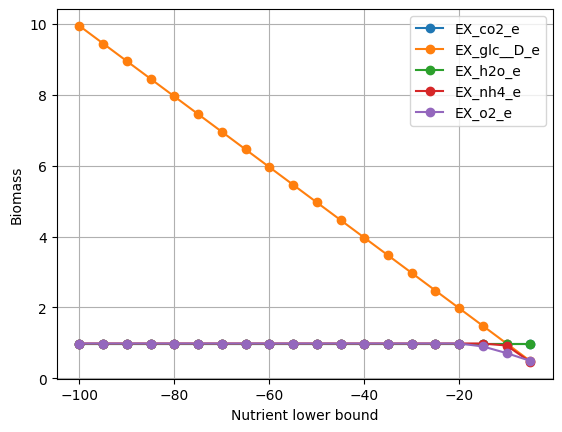

In [56]:
for nutrient, values in outputs.items():
    plt.plot(range(-100, 0, 5), values, marker='o', label=nutrient)
plt.xlabel("Nutrient lower bound")
plt.ylabel("Biomass")
plt.legend()
plt.grid(True)

In [55]:
# Of these, let's pick a subset [Glucose, O2, H20, CO2, Ammonium, phosphate]
# Adjust the lower bounds in range(-1000, 0, 100) and record the effect on biomass flux
# Plot curves of biomass vs uptake rate curves
outputs = {}
for nutrient in ['EX_co2_e', 'EX_glc__D_e', 'EX_h2o_e', 'EX_nh4_e', 'EX_o2_e']:
    orig_lb = model.reactions.get_by_id(nutrient).lower_bound
    outputs[nutrient] = []
    for low_bound in range(-100, 0, 5):
        model.reactions.get_by_id(nutrient).lower_bound = low_bound
        outputs[nutrient].append(model.optimize().objective_value)
    model.reactions.get_by_id(nutrient).lower_bound = orig_lb

        

In [ ]:
# Baseline growth/biomass, uptake and secretion
model.summary()
# redox balance
model.metabolits.nadh_c.summary()
# Main energy production and consumption reactions
model.metabolites.atp_c.summary()